In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, LeakyReLU, Flatten, Reshape
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
from tensorflow.keras.optimizers import Adam

In [3]:
# Load the MNIST dataset
(x_train, _), (_, _) = mnist.load_data()
x_train = (x_train.astype('float32') - 127.5) / 127.5  # Normalize to [-1, 1]
x_train = np.expand_dims(x_train, axis=-1)  # Reshape for the network (batch, 28, 28, 1)

# Parameters
img_shape = (28, 28, 1)
latent_dim = 10

In [4]:
# Encoder definition
encoder_input = Input(shape=img_shape)
x = Flatten()(encoder_input)
x = Dense(512, activation='relu')(x)
z = Dense(latent_dim)(x)
encoder = Model(encoder_input, z)

In [5]:
# Decoder definition
decoder_input = Input(shape=(latent_dim,))
x = Dense(512, activation='relu')(decoder_input)
x = Dense(int(np.prod(img_shape)), activation='tanh')(x)
decoder_output = Reshape(img_shape)(x)
decoder = Model(decoder_input, decoder_output)

In [6]:
# Discriminator definition
discriminator_input = Input(shape=(latent_dim,))
x = Dense(512, activation='relu')(discriminator_input)
discriminator_output = Dense(1, activation='sigmoid')(x)
discriminator = Model(discriminator_input, discriminator_output)
discriminator.compile(loss='binary_crossentropy', optimizer=Adam(0.0002, 0.5), metrics=['accuracy'])

In [7]:
# Autoencoder (encoder + decoder)
autoencoder_input = Input(shape=img_shape)
encoded_img = encoder(autoencoder_input)
decoded_img = decoder(encoded_img)
autoencoder = Model(autoencoder_input, decoded_img)
autoencoder.compile(loss='mse', optimizer=Adam(0.0002, 0.5))

In [8]:
# Training
batch_size = 128
epochs = 1000

for epoch in range(epochs):
    idx = np.random.randint(0, x_train.shape[0], batch_size)
    imgs = x_train[idx]

    # Generate fake examples
    latent_fake = np.random.normal(0, 1, (batch_size, latent_dim))
    gen_imgs = decoder.predict(latent_fake)

    # Train discriminator
    d_loss_real = discriminator.train_on_batch(encoder.predict(imgs), np.ones((batch_size, 1)))
    d_loss_fake = discriminator.train_on_batch(latent_fake, np.zeros((batch_size, 1)))
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    # Train autoencoder
    g_loss = autoencoder.train_on_batch(imgs, imgs)

    print(f"Epoch {epoch + 1}/{epochs}, D Loss: {d_loss[0]:.4f}, Acc: {100*d_loss[1]:.2f}%, G Loss: {g_loss:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Epoch 1/1000, D Loss: 0.7098, Acc: 42.19%, G Loss: 0.9809
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Epoch 2/1000, D Loss: 0.6981, Acc: 48.76%, G Loss: 0.9569
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Epoch 3/1000, D Loss: 0.6796, Acc: 56.38%, G Loss: 0.9458
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Epoch 4/1000, D Loss: 0.6645, Acc: 60.99%, G Loss: 0.9345
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Epoch 5/1000, D Loss: 0.6451, Acc: 63.66%, G Loss: 0.9210
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Epoch 6/1000, D Loss: 0.6216, Acc: 65.45%, G Loss: 0.9049
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Epoch 7/1000, D Loss: 0.5976, Acc: 66.89%, G Loss: 0.8871
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6m

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step


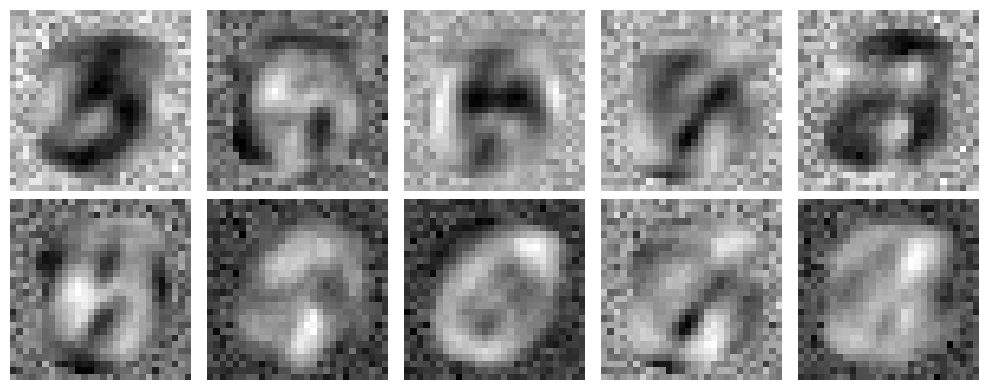

In [9]:
# Function to display generated images
def display_images(n=10):
    z_sample = np.random.normal(0, 1, (n, latent_dim))
    gen_imgs = decoder.predict(z_sample)
    plt.figure(figsize=(10, 4))
    for i in range(n):
        ax = plt.subplot(2, 5, i + 1)
        plt.imshow(gen_imgs[i, :, :, 0], cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

display_images()